# Exchange Netflows — a quantitative teardown 🔬
### netflow→forward-return slope · high-vs-low Welch *t* · label-shuffle placebo · lag/threshold sweep · costs & borrow · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Would_the_engine_catch_it%3F: Yes](https://img.shields.io/badge/Would_the_engine_catch_it%3F-Yes-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The claim: exchange net-inflow (coins TO exchanges) is a bearish lead for BTC's forward return.

> ⚠️ **Not investment advice.** **Synthetic-only:** a real BTC exchange-netflow tape is a paywalled address-clustering product (Glassnode / CryptoQuant / Nansen), so there is no real tape and a `REAL` stamp (robust *t* ≥ 2 on real data) is unreachable by construction — the study is capped at NONE. All computed cells run the deterministic synthetic world (seed 584, series fp `8c7301772d7b`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from exchange_netflows import data, strategy as st

# SYNTHETIC-ONLY: a real BTC exchange-netflow tape is a paywalled address-clustering product,
# so there is NO real tape here (HAVE_REAL is always False, by design). Every computed cell runs
# the deterministic synthetic world, seed 584 — offline and reproducible.
HAVE_REAL = False
NULL, _ = data.synthetic_series(bear_beta=0.0, seed=584)        # the honest null world
print("synthetic null world:", len(NULL), "days | series fp", data.fingerprint(NULL),
      "| HAVE_REAL", HAVE_REAL)


synthetic null world: 1500 days | series fp 8c7301772d7b | HAVE_REAL False


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No real tape (paid product). Null-world slope of forward return on z(net-inflow) **+4.3 bps/σ** (*t* **0.47**); sort spread **+10.3 bps** (Welch *t* 0.38, placebo *p* 0.72). Synthetic-only → capped. |
| **Tradability** | `MIRAGE` | Data unreachable; simulated book gross **-1.1 bps** → net **-6.4 bps** (10 bps/turn + 300 bps/yr borrow), mean net Sharpe **-0.32** (25 seeds). |
| **Would the engine catch it?** | `YES` | Planted `bear_beta −0.0025`: mean slope-*t* **-2.78** (25 seeds); single seed sort spread **+80 bps** (*t* 2.95, placebo *p* 0.005). |

> 💡 In plain words: the harness is faithful (the control proves it), but the underlying netflow series is paywalled — so there is nothing real to certify, and a fair null is empty.

## 1 · The claim, steelmanned

Let $F_t$ be the standardised exchange net-inflow on day $t$ and $r_{t\to t+h}$ the forward BTC return over $(t, t+h]$.

- **H₁ (slope / folklore).** $\text{slope of } r_{t\to t+h} \text{ on } F_t < 0$ at *t* ≤ −2 (more inflow → lower forward return).
- **H₂ (sort).** $\mathbb{E}[r \mid \text{low inflow}] - \mathbb{E}[r \mid \text{high inflow}] > 0$ (net-outflow days beat net-inflow days).
- **H₃ (robustness).** The sign holds across execution lags and tail thresholds.
- **H₄ (net).** The signal-timed book survives costs and the short borrow.

**The catch is upstream of all four:** $F_t$ itself — an *exchange-labelled* on-chain quantity — is a paid clustering product. With no real $F_t$, none of H₁–H₄ can be certified on a real tape, so the study is synthetic-only and stamps `NONE`. We instead (a) confirm the null is empty and (b) prove the engine catches a *planted* effect.

## 2 · So what? — the data-availability wall

A netflow is *defined* by which addresses belong to which exchange. Building that map means clustering millions of on-chain addresses into exchange cold/hot wallets — the proprietary moat Glassnode, CryptoQuant, Nansen and Chainalysis sell behind paid keys with no usable free history. The public chain gives **transfers, not labels**. Per the house inference bar, a study with no real tape is capped at `WEAK`/`NONE` — literature and a synthetic control are never market evidence. That places this beside the other *unreachable-data* studies while the tradable crypto tape lives in [133](../../133-crypto-seasonality/) / [210](../../210-crypto-trend/) / [325](../../325-crypto-fear-greed/).

## 3 · How we'd know — the protocol

- **Signal.** Standardise net-inflow to $F_t = z(\text{netflow})$.
- **H₁.** OLS of $r_{t\to t+h}$ on $F_t$; the *sign* of the slope is the folklore.
- **H₂.** Split days into the top/bottom $q$ by $F_t$; Welch two-sample *t* on the two tails' forward returns.
- **Placebo.** Shuffle $F_t$ against forward returns (2000 perms); tail probability of the spread.
- **Robustness.** Sweep lags $\{1,2,3,5\}$ and tail fractions $\{0.1,0.2,0.3\}$.
- **Frictions.** Signal-timed long/short book; one-way cost per turn + annual short borrow pro-rated over the hold.
- **Positive control.** A planted world ($\texttt{bear\_beta}<0$) and a null, averaged over 25 seeds (house rule).

Timing: $F_t$ is public at day-$t$ close; tested against $(t, t+h]$. One documented lag (default $h=1$); no future data enters the signal.

## 4 · The teardown

### 4a · The slope — H₁ (null world)

Regress the forward BTC return on standardised net-inflow. A *negative* slope would be the folklore.

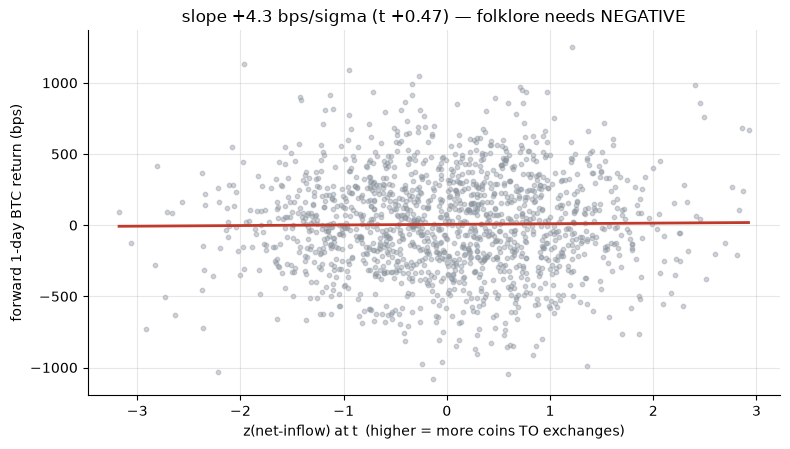

slope +4.29 bps/sigma | t +0.47 | corr +0.0122 | n 1499


In [2]:
reg = st.flow_regression(NULL, lag=1)
a = st.aligned(NULL, lag=1)
x = a['z_flow'].to_numpy(); y = a['fwd'].to_numpy()*1e4
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=10, color=GREY, alpha=.4)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (reg['slope']*xs + (a['fwd'].mean() - reg['slope']*a['z_flow'].mean()))*1e4, c=RED, lw=2)
ax.set_xlabel('z(net-inflow) at t  (higher = more coins TO exchanges)')
ax.set_ylabel('forward 1-day BTC return (bps)')
ax.set_title(f"slope {reg['slope']*1e4:+.1f} bps/sigma (t {reg['slope_t']:+.2f}) — folklore needs NEGATIVE")
plt.tight_layout(); plt.show()
print(f"slope {reg['slope']*1e4:+.2f} bps/sigma | t {reg['slope_t']:+.2f} | corr {reg['corr']:+.4f} | n {reg['n']}")

> 💡 In plain words: H₁ **not supported** — the slope is **+4.3 bps/σ** (*t* 0.47), a statistical zero and, if anything, the *wrong* sign. In a world where netflow carries no info, the engine correctly reads no info.

### 4b · The sort + placebo — H₂

High-inflow vs low-inflow forward returns, with the Welch *t* and the label-shuffle placebo.

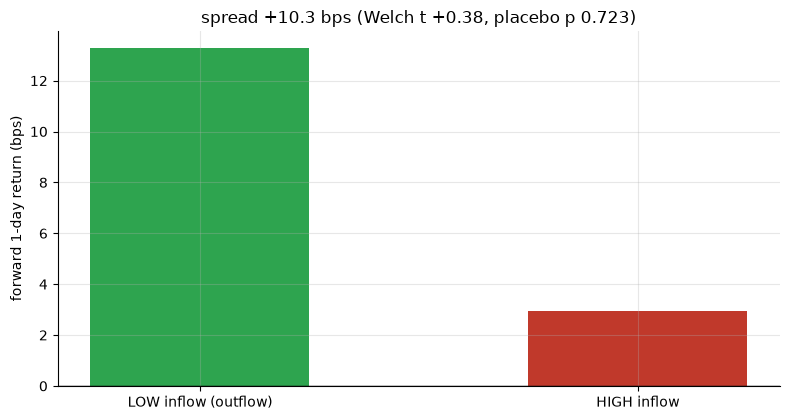

low +13.3 | high +2.9 | spread +10.3 bps | Welch t +0.38 | placebo p 0.723


In [3]:
ss = st.sort_spread(NULL, lag=1, frac=0.2)
p = st.placebo_pvalue(NULL, lag=1, frac=0.2, n_perm=2000, seed=584)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['LOW inflow (outflow)','HIGH inflow'],
       [ss['low_inflow_mean']*1e4, ss['high_inflow_mean']*1e4], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 1-day return (bps)')
ax.set_title(f"spread {ss['spread']*1e4:+.1f} bps (Welch t {ss['t']:+.2f}, placebo p {p:.3f})")
plt.tight_layout(); plt.show()
print(f"low {ss['low_inflow_mean']*1e4:+.1f} | high {ss['high_inflow_mean']*1e4:+.1f} | spread {ss['spread']*1e4:+.1f} bps | Welch t {ss['t']:+.2f} | placebo p {p:.3f}")

> 💡 In plain words: H₂ **not supported** — the spread is **+10.3 bps** (Welch *t* 0.38) and the placebo *p* = 0.72 sits mid-distribution. No difference between high- and low-inflow days beyond noise.

### 4c · Robustness — H₃ (lags × thresholds)

Does any lag or tail choice hide a signal?

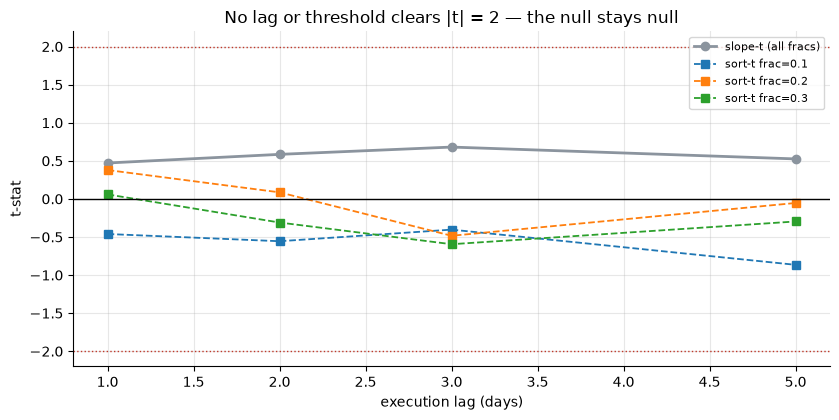

 lag  frac  slope_t  sort_spread_bps  sort_t
   1   0.1    0.471          -17.458  -0.461
   1   0.2    0.471           10.345   0.379
   1   0.3    0.471            1.363   0.059
   2   0.1    0.585          -31.085  -0.555
   2   0.2    0.585            3.381   0.086
   2   0.3    0.585          -10.155  -0.310
   3   0.1    0.681          -25.991  -0.403
   3   0.2    0.681          -23.237  -0.484
   3   0.3    0.681          -23.821  -0.595
   5   0.1    0.525          -74.435  -0.865
   5   0.2    0.525           -3.428  -0.053
   5   0.3    0.525          -15.725  -0.296


In [4]:
sw = st.robustness_sweep(NULL)
piv = sw.pivot(index='lag', columns='frac', values='sort_t')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
slope_ts = sw.drop_duplicates('lag').set_index('lag')['slope_t']
ax.plot(slope_ts.index, slope_ts.values, 'o-', c=GREY, lw=2, label='slope-t (all fracs)')
for fr in sorted(sw['frac'].unique()):
    sub = sw[sw['frac']==fr]
    ax.plot(sub['lag'], sub['sort_t'], 's--', lw=1.3, label=f'sort-t frac={fr}')
ax.axhline(2, ls=':', c=RED, lw=1); ax.axhline(-2, ls=':', c=RED, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('execution lag (days)'); ax.set_ylabel('t-stat')
ax.set_title('No lag or threshold clears |t| = 2 — the null stays null'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(sw.round(3).to_string(index=False))

> 💡 In plain words: H₃ moot — every slope-*t* sits between +0.47 and +0.68, every sort-*t* well inside ±1. There is no fragile corner where a signal hides; the null is null everywhere.

## 5 · The verdict

- **Signal `NONE`** — no real tape (paid product); null-world slope-*t* **0.47**, sort *t* 0.38, placebo *p* 0.72. Synthetic-only caps the stamp.
- **Tradability `MIRAGE`** — data unreachable; simulated book net **-6.4 bps**, mean net Sharpe -0.32.
- **Would the engine catch it? `YES`** — the planted control clears the bar (Beat 7).

## 6 · Could you trade it? — costs and the borrow

Even setting the missing data aside, sign-timing the netflow in the null world bleeds.

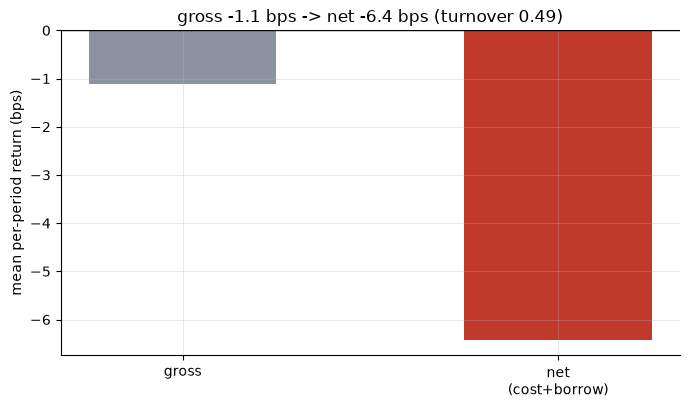

gross -1.1 bps -> net -6.4 bps | mean gross Sharpe +0.00 -> net -0.32 (25 seeds)


In [5]:
stt = st.strategy_stats(NULL, lag=1, band=0.5, cost_bps=10.0, borrow_ann_bps=300.0)
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(cost+borrow)'], [stt['gross_mean']*1e4, stt['net_mean']*1e4],
       color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean per-period return (bps)')
ax.set_title(f"gross {stt['gross_mean']*1e4:+.1f} bps -> net {stt['net_mean']*1e4:+.1f} bps (turnover {stt['turnover']:.2f})")
plt.tight_layout(); plt.show()
gs, ns = [], []
for s in range(584, 584+25):
    fr,_ = data.synthetic_series(bear_beta=0.0, seed=s)
    d = st.strategy_stats(fr, lag=1); gs.append(d['gross_sharpe']); ns.append(d['net_sharpe'])
print(f"gross {stt['gross_mean']*1e4:+.1f} bps -> net {stt['net_mean']*1e4:+.1f} bps | "
      f"mean gross Sharpe {np.nanmean(gs):+.2f} -> net {np.nanmean(ns):+.2f} (25 seeds)")

> 💡 In plain words: gross ≈ 0, net **-6.4 bps** — the turnover cost and short borrow turn a nothing-signal into a slow loss. Mean net Sharpe **-0.32** across 25 seeds. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant the folklore (`bear_beta < 0`) of increasing strength and watch the flow→return slope-*t* go negative — averaged over 25 seeds so no single lucky seed can fake it.

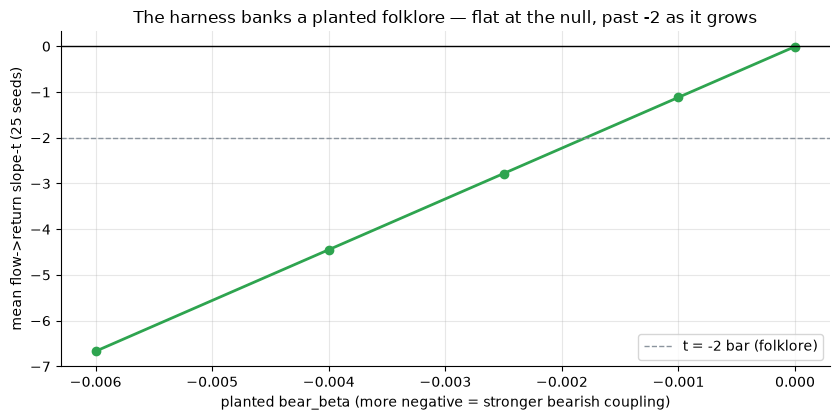

bear_beta +0.0000 -> mean slope-t -0.01
bear_beta -0.0010 -> mean slope-t -1.12
bear_beta -0.0025 -> mean slope-t -2.78
bear_beta -0.0040 -> mean slope-t -4.45
bear_beta -0.0060 -> mean slope-t -6.67


planted seed: sort spread +80 bps (t +2.95, placebo p 0.005); book gross Sharpe +0.97 -> net +0.66


In [6]:
betas = [0.0, -0.001, -0.0025, -0.004, -0.006]
ts = [st.synthetic_mean_t(b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (folklore)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted bear_beta (more negative = stronger bearish coupling)')
ax.set_ylabel('mean flow->return slope-t (25 seeds)')
ax.set_title('The harness banks a planted folklore — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'bear_beta {b:+.4f} -> mean slope-t {t:+.2f}')
# and a single planted seed's tradable book, for colour
P,_ = data.synthetic_series(bear_beta=-0.0025, seed=584)
ssP = st.sort_spread(P, lag=1, frac=0.2); pP = st.placebo_pvalue(P, lag=1, frac=0.2, n_perm=2000)
sttP = st.strategy_stats(P, lag=1)
print(f"planted seed: sort spread {ssP['spread']*1e4:+.0f} bps (t {ssP['t']:+.2f}, placebo p {pP:.3f}); "
      f"book gross Sharpe {sttP['gross_sharpe']:+.2f} -> net {sttP['net_sharpe']:+.2f}")

The slope-*t* is ≈ 0 at the null and falls past −2 by `bear_beta = -0.0025` (mean **-2.78**, 25 seeds), reaching **-6.67** at the strong setting — and a single planted seed's book earns a real gross Sharpe **0.97**. **So the engine is a faithful detector.** The empty real-side result is therefore a statement about **data availability**, not a blind test: the netflow tape is paywalled, so the folklore cannot be certified here. For the crypto claims a free stack *can* reach, see [133 Crypto-Seasonality](../../133-crypto-seasonality/), [210 Crypto-Trend](../../210-crypto-trend/) and [325 Crypto-Fear-Greed](../../325-crypto-fear-greed/).